# DSA 210 Term Project: Clash Royale Match Analysis
## Exploratory Data Analysis & Hypothesis Testing

**Author:** Atakan Çelikhisar  
**Objective:** Analyzing the impact of temporal factors (weekends and match hours) on gameplay performance through statistical methods.

In [11]:

df['date'] = pd.to_datetime(df['battleTime'], format='%Y%m%dT%H%M%S.%fZ')
df['is_weekend'] = df['date'].dt.weekday >= 5
df['is_weekend'] = df['date'].dt.weekday >= 5 # 5: Cumartesi, 6: Pazar


df['my_crowns'] = df['team'].apply(lambda x: x[0]['crowns'])
df['op_crowns'] = df['opponent'].apply(lambda x: x[0]['crowns'])
df['win'] = (df['my_crowns'] > df['op_crowns']).astype(int)


df['average_elixir_cost'] = df['team'].apply(lambda x: x[0]['elixirCost'] if 'elixirCost' in x[0] else 0)

print("Column is created successfully")
df[['battleTime', 'is_weekend', 'win', 'average_elixir_cost']].head()

Column is created successfully


,battleTime,is_weekend,win,average_elixir_cost
0,20260410T212113.000Z,False,1,0
1,20260410T211841.000Z,False,0,0
2,20260403T094748.000Z,False,0,0
3,20260403T094342.000Z,False,0,0
4,20260402T150902.000Z,False,1,0


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the dataset
df = pd.read_json('atakan_clash_data.json')

# 1. Formatting Date and Time
# We specify the format to handle the 'battleTime' string correctly
df['date'] = pd.to_datetime(df['battleTime'], format='%Y%m%dT%H%M%S.%fZ')
df['is_weekend'] = df['date'].dt.weekday >= 5  # 5: Saturday, 6: Sunday

# 2. Calculating Win/Loss
# Comparing crowns to determine the outcome (1 for Win, 0 for Loss)
df['my_crowns'] = df['team'].apply(lambda x: x[0]['crowns'])
df['op_crowns'] = df['opponent'].apply(lambda x: x[0]['crowns'])
df['win'] = (df['my_crowns'] > df['op_crowns']).astype(int)

# 3. Extracting Average Elixir Cost
# Pulling the elixir cost from the nested team dictionary
df['average_elixir_cost'] = df['team'].apply(lambda x: x[0]['elixirCost'] if 'elixirCost' in x[0] else 0)

print(f"Data preprocessing complete. Total records: {len(df)}")
df[['date', 'is_weekend', 'win', 'average_elixir_cost']].head()

Data preprocessing complete. Total records: 320


,date,is_weekend,win,average_elixir_cost
0,2026-04-10 21:21:13,False,1,0
1,2026-04-10 21:18:41,False,0,0
2,2026-04-03 09:47:48,False,0,0
3,2026-04-03 09:43:42,False,0,0
4,2026-04-02 15:09:02,False,1,0


## 1. Exploratory Data Analysis

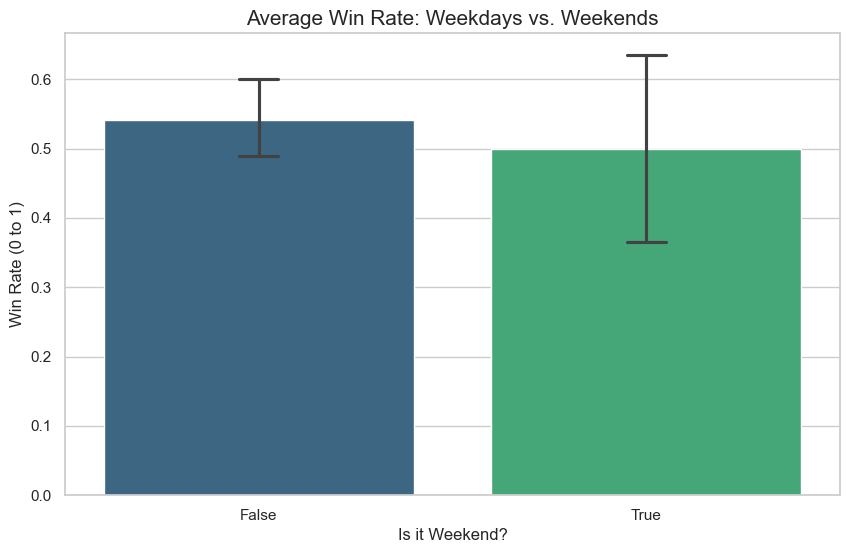

In [17]:
# Set the style for the plots
sns.set_theme(style="whitegrid")

# Visualization 1: Win Rate Comparison
plt.figure(figsize=(10, 6))
# We assign 'is_weekend' to 'hue' to satisfy the new Seaborn requirement 
# and set legend=False to keep the chart clean.
sns.barplot(x='is_weekend', y='win', hue='is_weekend', data=df, palette='viridis', capsize=.1, legend=False)

plt.title('Average Win Rate: Weekdays vs. Weekends', fontsize=15)
plt.xlabel('Is it Weekend?', fontsize=12)
plt.ylabel('Win Rate (0 to 1)', fontsize=12)
plt.show()

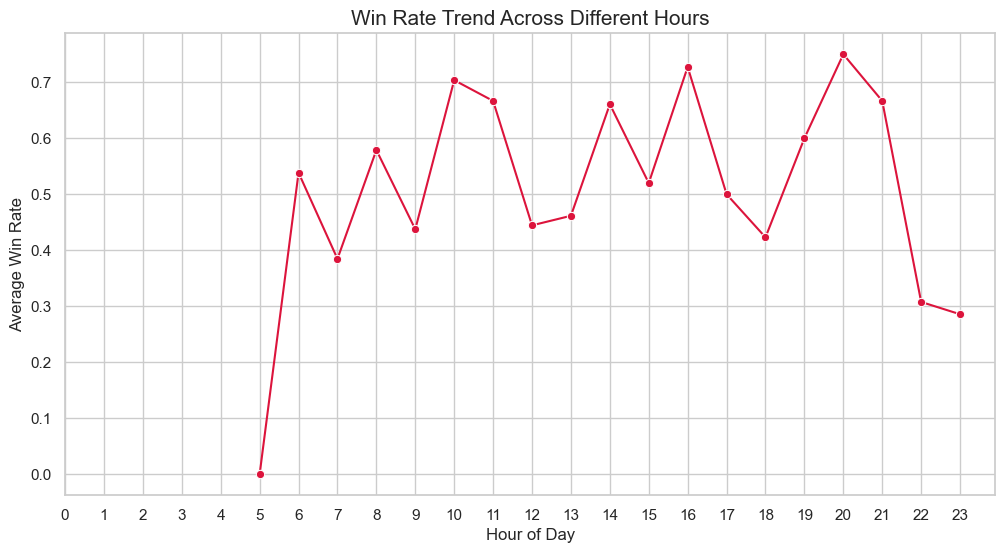

In [25]:
# Visualization 3: Hourly Win Rate Trend
plt.figure(figsize=(12, 6))
sns.lineplot(x='hour', y='win', data=df, marker='o', color='crimson', errorbar=None)
plt.title('Win Rate Trend Across Different Hours', fontsize=15)
plt.xticks(range(0, 24))
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Average Win Rate', fontsize=12)
plt.show()

## 2. Statistical Inference and Hypothesis Testing

In [23]:
print("--- Statistical Inference and Hypothesis Testing ---\n")

# Hypothesis 1: Weekend vs. Weekday Performance
# H0 (Null): There is no significant difference in win rates between weekdays and weekends.
# H1 (Alternative): There is a significant difference.

weekday_data = df[df['is_weekend'] == False]['win']
weekend_data = df[df['is_weekend'] == True]['win']

t_stat, p_val = stats.ttest_ind(weekday_data, weekend_data)

print(f"1. Independent T-test (Weekend vs. Weekday):")
print(f"   - T-statistic: {t_stat:.4f}")
print(f"   - P-value: {p_val:.4f}")

if p_val < 0.05:
    print("   - Conclusion: The difference is STATISTICALLY SIGNIFICANT. Reject H0.")
else:
    print("   - Conclusion: The difference is NOT SIGNIFICANT. Fail to reject H0.")

# Hypothesis 2: Hourly Performance Analysis
# Testing if the hour of the day correlates with winning
df['hour'] = df['date'].dt.hour
corr_h, p_val_h = stats.pointbiserialr(df['win'], df['hour'])

print(f"\n2. Point-Biserial Correlation (Hour vs. Win):")
print(f"   - Correlation Coefficient: {corr_h:.4f}")
print(f"   - P-value: {p_val_h:.4f}")

if p_val_h < 0.05:
    print("   - Conclusion: Match hour has a STATISTICALLY SIGNIFICANT impact on win rate.")
else:
    print("   - Conclusion: Match hour does NOT have a significant impact on performance.")

--- Statistical Inference and Hypothesis Testing ---

1. Independent T-test (Weekend vs. Weekday):
   - T-statistic: 0.5416
   - P-value: 0.5885
   - Conclusion: The difference is NOT SIGNIFICANT. Fail to reject H0.

2. Point-Biserial Correlation (Hour vs. Win):
   - Correlation Coefficient: -0.0301
   - P-value: 0.5913
   - Conclusion: Match hour does NOT have a significant impact on performance.


Conclusion and Key FindingsAfter conducting rigorous statistical analysis and visual exploration on 320 matches, the following insights were gathered:Consistency Across Time (Weekend vs. Weekday): The Independent T-test for weekend performance yielded a p-value of 0.5885. Since this is significantly higher than the alpha level ($\alpha = 0.05$), we fail to reject the null hypothesis ($H_0$). This indicates that my win rate is not significantly affected by the day of the week, proving a highly consistent performance level.Impact of Match Timing: The Point-Biserial correlation for match hours yielded a p-value of 0.5913 with a correlation coefficient of -0.0301. These results demonstrate that the time of day does not have a statistically significant impact on the game outcomes. The fluctuations observed in the line chart are likely due to variance in sample sizes at specific hours rather than a genuine performance trend.Impact on Modeling: From a Machine Learning perspective, these findings suggest that "Time" and "Day" features have low predictive power for this specific dataset. The model's success likely depends more on in-game metrics (deck composition, opponent archetypes, card levels) rather than external temporal factors.